In [65]:
import pandas as pd

df = pd.read_csv("../data/raw/screen_time_mental_health.csv")
df.head()

,subject_id,sex,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,bdi_total,depressed
0,1,Boy,3.333,4.64,2.25,8.36,4.58,1.92,6,0
1,2,Girl,3.333,4.07,2.50,7.31,5.42,2.25,7,0
2,3,Boy,3.333,4.07,2.00,8.75,5.50,2.62,27,1
3,4,Boy,4.333,6.07,1.50,8.17,6.62,3.96,22,1
4,5,Boy,1.667,0.50,2.50,8.88,4.12,1.79,3,0


## Paso 4: Realiza un análisis descriptivo


#### Antes de realizar el análisis descriptivo, veremos el significado de cada variable y luego un resumen rápido de nuestros datos:

 - ***subject_id:*** Identificador único de cada participante

 - ***sex:*** Sexo de la persona participante

 - ***screen_time_index:*** Índice que resume el nivel de exposición/uso de pantallas

 - ***est_leisure_screen_hours:*** Horas estimadas de uso de pantallas durante el tiempo libre

 - ***sleep_quality_index:*** Índice que representa la calidad del sueño

 - ***avg_sleep_hours:*** Promedio de horas de sueño

 - ***midsleep_weekend_hours:*** Hora media del sueño durante los fines de semana

 - ***social_jetlag_hours:*** Diferencia entre los horarios de sueño de días laborales y fines de semana

 - ***bdi_total:*** Puntaje total de síntomas depresivos según el BDI

 - ***depressed:*** Indicador de si la persona supera un determinado umbral de síntomas depresivos

In [66]:
df.describe()

,subject_id,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,bdi_total,depressed
count,4810.000000,4810.000000,4810.000000,4810.000000,4810.000000,4810.000000,4810.000000,4810.000000,4810.000000
mean,2405.500000,3.219097,3.958299,1.901611,7.689067,5.570553,2.400200,7.271518,0.163617
std,1388.671727,1.026348,2.387289,0.851176,1.270213,1.415505,1.137931,7.703156,0.369967
min,1.000000,1.000000,0.500000,1.000000,1.360000,1.670000,-3.030000,0.000000,0.000000
25%,1203.250000,2.333000,2.070000,1.250000,7.050000,4.540000,1.580000,2.000000,0.000000
50%,2405.500000,3.000000,3.500000,1.750000,7.870000,5.420000,2.290000,5.000000,0.000000
75%,3607.750000,4.000000,5.500000,2.250000,8.540000,6.500000,3.120000,10.000000,0.000000
max,4810.000000,6.000000,10.000000,6.000000,12.210000,10.500000,6.960000,51.000000,1.000000


Ahora agregaremos la Moda, las medidas de dispersión (Varianza y Desviación Estándar) y las medidas de formas (Curtosis y Asimetría) de cada una de las variables predictoras para enriquecer nuestro análisis, dejando fuera la variable ***'subject_id'*** que no debería utilizarse como predictor porque es simplemente un identificador y ***'depressed'***, que tampoco conviene incluirlo si es una variable construida a partir de ***'bdi_total'***.

In [67]:
#df.describe()

variables = [
    "screen_time_index",
    "est_leisure_screen_hours",
    "sleep_quality_index",
    "avg_sleep_hours",
    "midsleep_weekend_hours",
    "social_jetlag_hours", 
    "bdi_total"
]

estadisticas = pd.DataFrame({
    "Media": df[variables].mean(),
    "Mediana": df[variables].median(),
    "Moda": df[variables].mode().iloc[0],
    "Desv. estándar": df[variables].std(),
    "Varianza": df[variables].var(),
    "Mínimo": df[variables].min(),
    "Q1": df[variables].quantile(0.25),
    "Q3": df[variables].quantile(0.75),
    "Máximo": df[variables].max(),
    "Asimetría": df[variables].skew(),
    "Curtosis": df[variables].kurt()
})

estadisticas.round(3)

,Media,Mediana,Moda,Desv. estándar,Varianza,Mínimo,Q1,Q3,Máximo,Asimetría,Curtosis
screen_time_index,3.219,3.00,2.333,1.026,1.053,1.00,2.333,4.00,6.00,0.505,-0.404
est_leisure_screen_hours,3.958,3.50,2.070,2.387,5.699,0.50,2.070,5.50,10.00,0.872,0.094
sleep_quality_index,1.902,1.75,1.250,0.851,0.725,1.00,1.250,2.25,6.00,1.470,2.537
avg_sleep_hours,7.689,7.87,8.430,1.270,1.613,1.36,7.050,8.54,12.21,-0.922,1.525
midsleep_weekend_hours,5.571,5.42,5.250,1.416,2.004,1.67,4.540,6.50,10.50,0.436,0.015
social_jetlag_hours,2.400,2.29,2.000,1.138,1.295,-3.03,1.580,3.12,6.96,0.382,0.412
bdi_total,7.272,5.00,1.000,7.703,59.339,0.00,2.000,10.00,51.00,1.889,4.315


#### Conclusiones por variables:

- ***screen_time_index:*** presenta una media de 3,22 y una mediana de 3, con dispersión moderada (DE = 1,03). La asimetría positiva (0,51) indica una ligera concentración de valores bajos-medios y algunos valores más altos. No presenta una dispersión extrema.

- ***est_leisure_screen_hours:*** el promedio es de 3,96 horas, con una mediana de 3,50. Tiene una dispersión relativamente alta (DE = 2,39) y una asimetría positiva (0,87), indicando que algunos individuos presentan muchas más horas de pantalla que la mayoría. El máximo de 10 horas refuerza esta observación.

- ***sleep_quality_index:*** presenta una media de 1,90 y una mediana de 1,75, con una dispersión moderada (DE = 0,85). La elevada asimetría positiva (1,47) y curtosis (2,54) muestran una distribución concentrada en valores bajos, pero con algunos valores considerablemente superiores.

- ***avg_sleep_hours:*** el promedio es de 7,69 horas, cercano a la mediana (7,87). La asimetría negativa (-0,92) indica una mayor concentración de observaciones en valores altos y algunos casos con pocas horas de sueño. La desviación estándar es de 1,27 horas, por lo que existe una variabilidad moderada.

- ***midsleep_weekend_hours:*** presenta una media de 5,57 y mediana de 5,42, con dispersión moderada (DE = 1,42). La asimetría es baja (0,44) y la curtosis cercana a cero (0,015), por lo que la distribución parece relativamente equilibrada y sin colas especialmente pronunciadas.

- ***social_jetlag_hours:*** tiene una media de 2,40 horas y mediana de 2,29, con una dispersión de 1,14 horas. La asimetría es leve (0,38) y la curtosis baja (0,41), lo que sugiere una distribución relativamente equilibrada. El mínimo negativo (-3,03) merece revisarse porque podría representar una situación particular de la variable o un posible valor atípico/error de medición.

- ***bdi_total:*** es la variable con mayor dispersión relativa (DE = 7,70) y presenta una fuerte asimetría positiva (1,89) y elevada curtosis (4,32). La mediana es 5, mientras que la media asciende a 7,27, debido a algunos valores elevados, llegando hasta 51. Esto indica que la mayoría de las observaciones tienen valores bajos de BDI, pero existe un grupo reducido con niveles de síntomas depresivos considerablemente superiores al resto.

#### Conclusiones generales: 
- En conjunto, las variables muestran distribuciones heterogéneas. 
- Las variables relacionadas con el sueño presentan comportamientos diferentes: ***'avg_sleep_hours'*** tiene asimetría negativa, mientras que ***'sleep_quality_index'*** presenta una marcada asimetría positiva. 
- Por otro lado, las variables de tiempo de pantalla muestran una tendencia hacia valores altos en algunos individuos. 
Finalmente, ***'bdi_total'*** destaca por su fuerte asimetría y presencia de valores extremos, algo especialmente importante de considerar posteriormente al construir un modelo de regresión.

Ahora procederemos a graficar las variables predictoras y la variable objetivo.

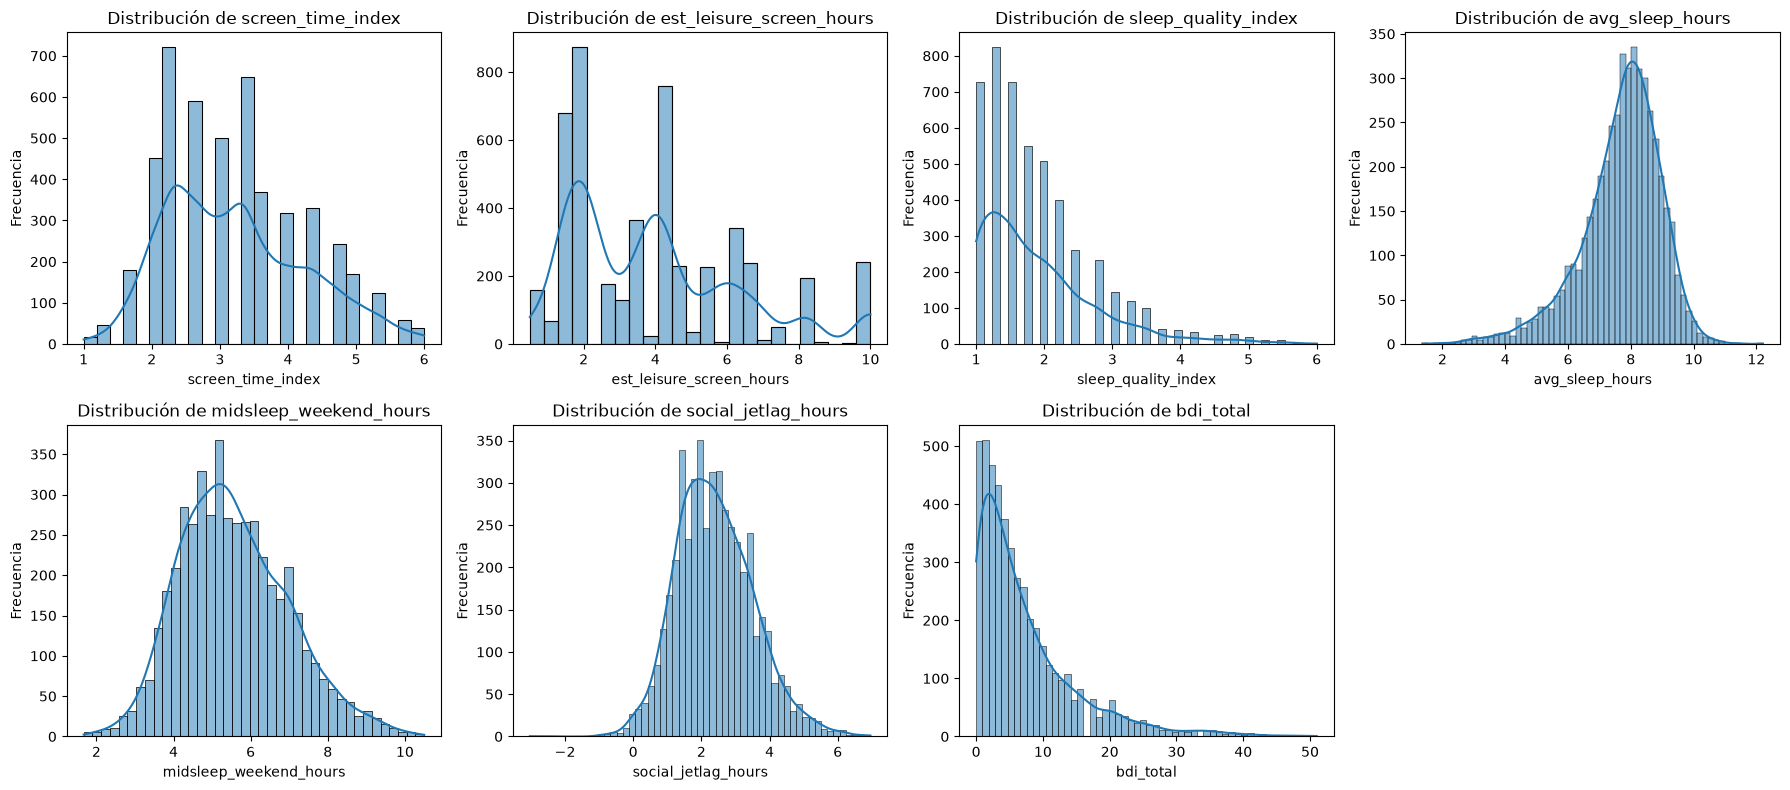

In [68]:

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for ax, variable in zip(axes.flatten(), variables):

    sns.histplot(
        data=df,
        x=variable,
        kde=True,
        ax=ax
    )

    ax.set_title(f"Distribución de {variable}")
    ax.set_xlabel(variable)
    ax.set_ylabel("Frecuencia")

# Ocultar el último gráfico que queda vacío
axes[1, 3].set_visible(False)

plt.tight_layout()
plt.show()

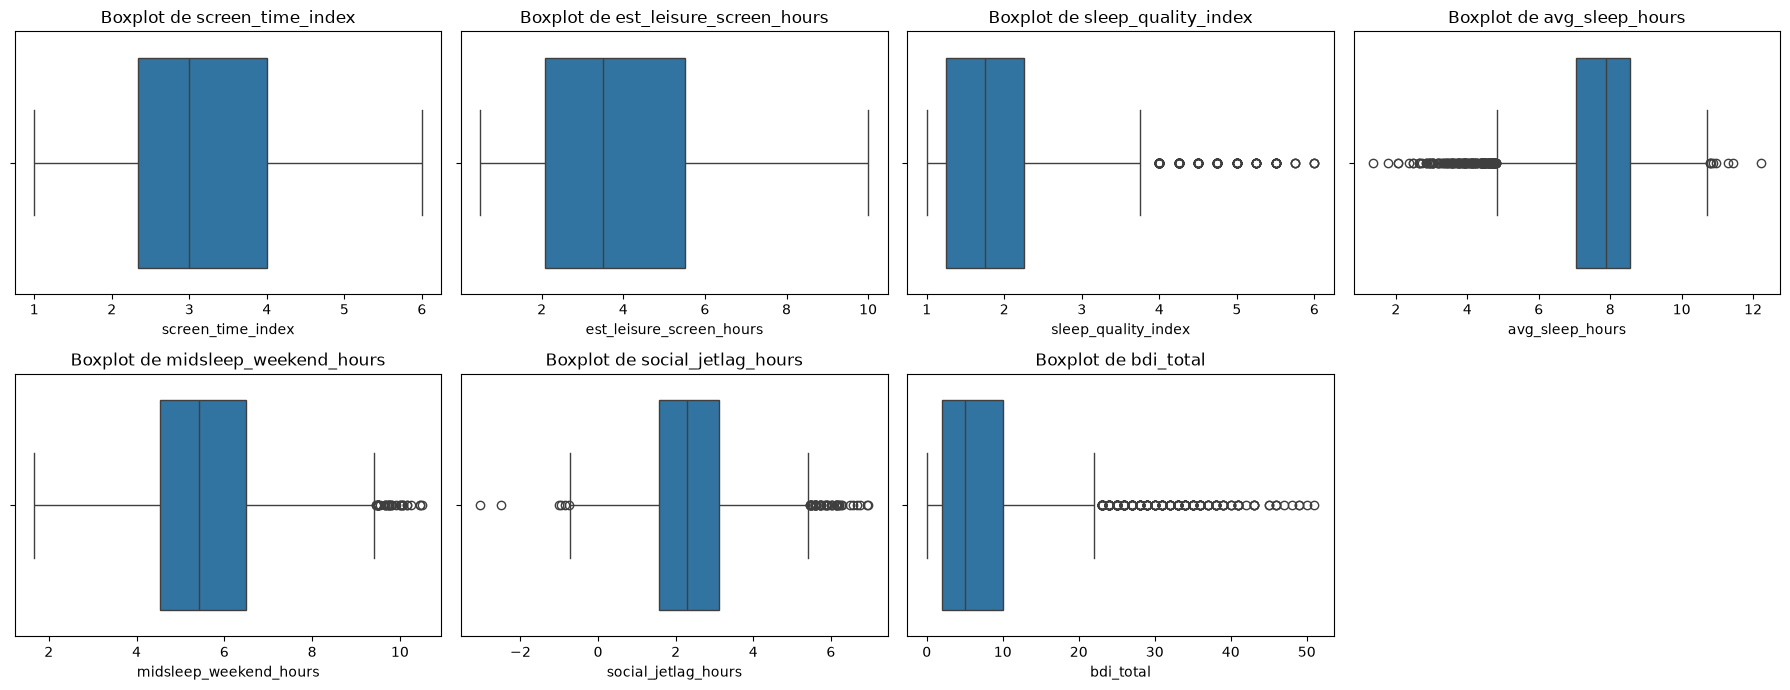

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 4, figsize=(18, 7))

for ax, variable in zip(axes.flatten(), variables):

    sns.boxplot(
        data=df,
        x=variable,
        ax=ax
    )

    ax.set_title(f"Boxplot de {variable}")
    ax.set_xlabel(variable)

# Ocultar el último gráfico que queda vacío
axes[1, 3].set_visible(False)

plt.tight_layout()
plt.show()

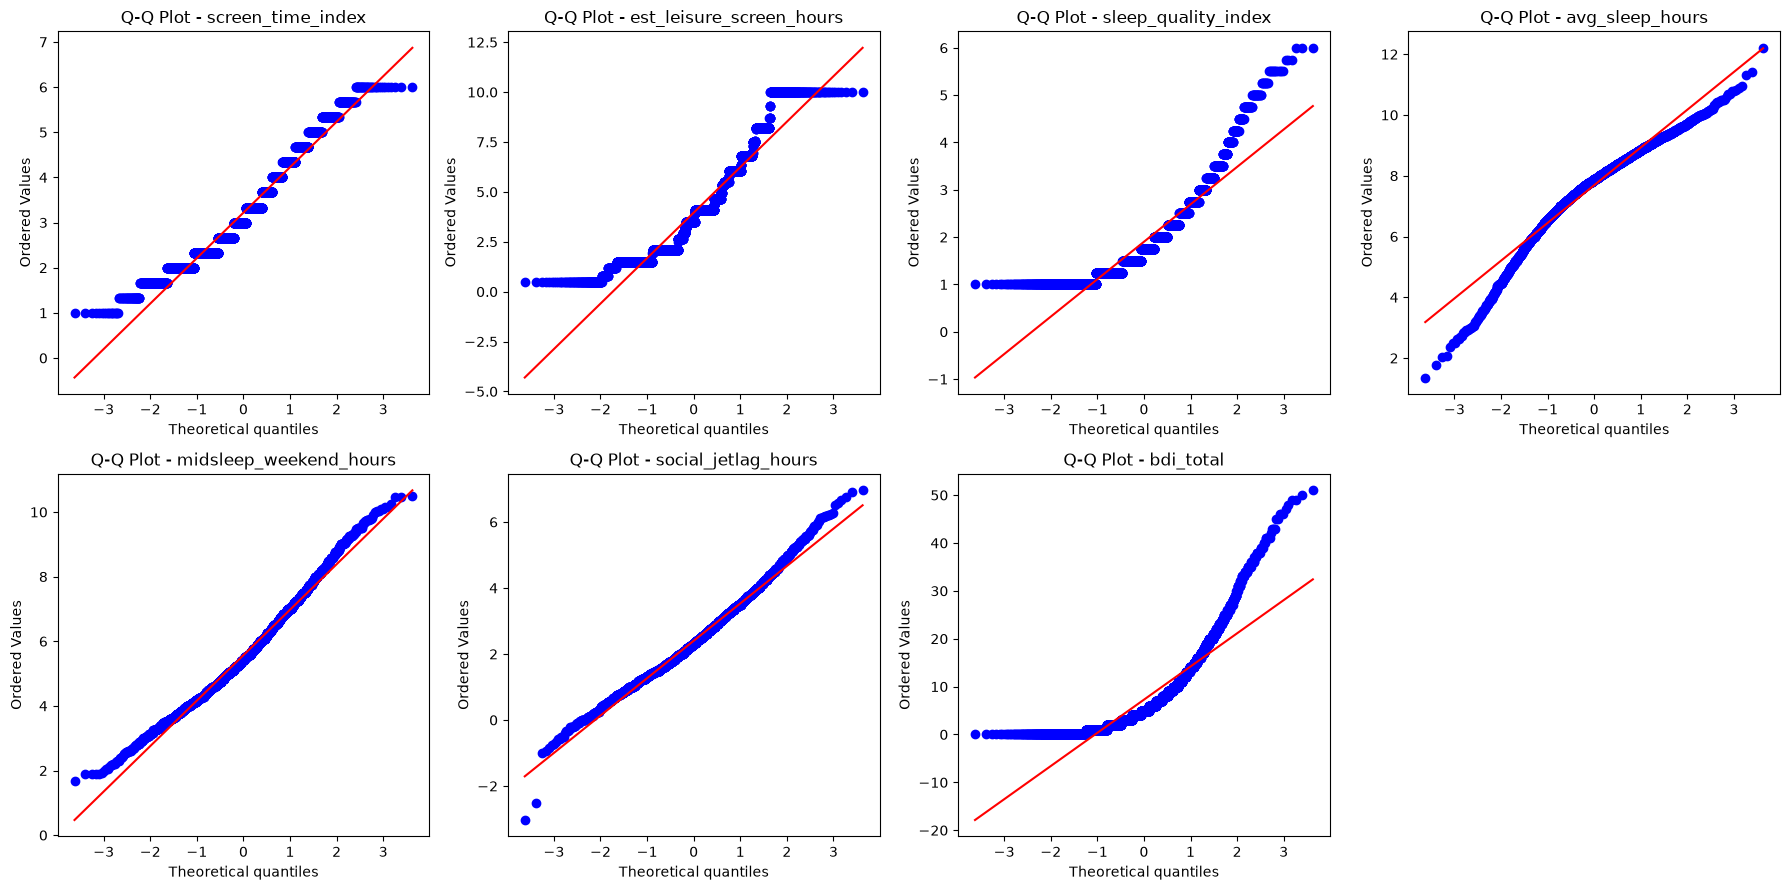

In [70]:
import matplotlib.pyplot as plt
import scipy.stats as stats

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for ax, variable in zip(axes.flatten(), variables):

    stats.probplot(
        df[variable].dropna(),
        dist="norm",
        plot=ax
    )

    ax.set_title(f"Q-Q Plot - {variable}")

# Ocultar el último espacio
axes[1, 3].set_visible(False)

plt.tight_layout()
plt.show()

- **screen_time_index:** distribución concentrada en valores intermedios, principalmente entre 2 y 4, con una ligera asimetría hacia la derecha. Hay pocos casos con niveles muy altos.

- **est_leisure_screen_hours:** distribución asimétrica a la derecha, concentrada aproximadamente entre 2 y 6 horas, pero con algunos individuos que alcanzan valores de hasta 10 horas.

- **sleep_quality_index:** distribución fuertemente asimétrica a la derecha. La mayoría presenta valores bajos (1–2,5), mientras que pocos casos alcanzan valores elevados.

- **avg_sleep_hours:** distribución aproximadamente unimodal y cercana a la normal, concentrada alrededor de 7–9 horas. Presenta una cola hacia valores bajos, coincidiendo con la asimetría negativa observada.

- **midsleep_weekend_hours:** distribución unimodal y relativamente simétrica, con mayor concentración alrededor de 5–6 horas. No se observan desviaciones extremas importantes.

- **social_jetlag_hours:** distribución aproximadamente simétrica y unimodal, concentrada alrededor de 2–3 horas. Presenta poca presencia de valores extremos.

- **bdi_total:** distribución fuertemente asimétrica a la derecha. La mayoría de los individuos presenta valores bajos de BDI, mientras que una cantidad reducida presenta valores elevados, llegando hasta aproximadamente 50. Esto evidencia posibles valores extremos. Conclusión general

Las variables sleep_quality_index y especialmente bdi_total presentan las distribuciones más alejadas de la normalidad. En cambio, avg_sleep_hours, midsleep_weekend_hours y social_jetlag_hours muestran distribuciones más equilibradas. Las variables relacionadas con tiempo de pantalla presentan cierta concentración en valores bajos/medios y una cola hacia valores altos.


Y la variable **'sex'** que es categórica/binaria, por lo que la vamos a analizar con: Frecuencia absoluta, Porcentaje, Moda y Gráfico de barras.

In [71]:
# Frecuencias
print(df["sex"].value_counts())

# Porcentajes
print(df["sex"].value_counts(normalize=True) * 100)

# Moda
print("Moda:", df["sex"].mode()[0])

sex
Boy     2446
Girl    2364
Name: count, dtype: int64
sex
Boy     50.852391
Girl    49.147609
Name: proportion, dtype: float64
Moda: Boy


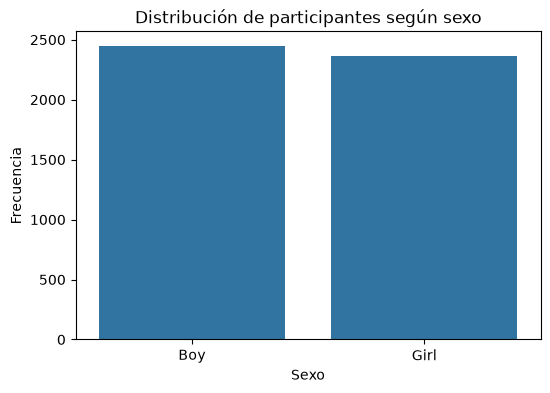

In [72]:

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="sex"
)

plt.title("Distribución de participantes según sexo")
plt.xlabel("Sexo")
plt.ylabel("Frecuencia")

plt.show()


En este caso ya sabemos que:

Boy: 2446 → 50,85%

Girl: 2364 → 49,15%

Por lo tanto, la distribución está muy equilibrada.


Veamos si existe relación entre el sexo y nuestra variable objetivo.

<Axes: xlabel='sex', ylabel='bdi_total'>

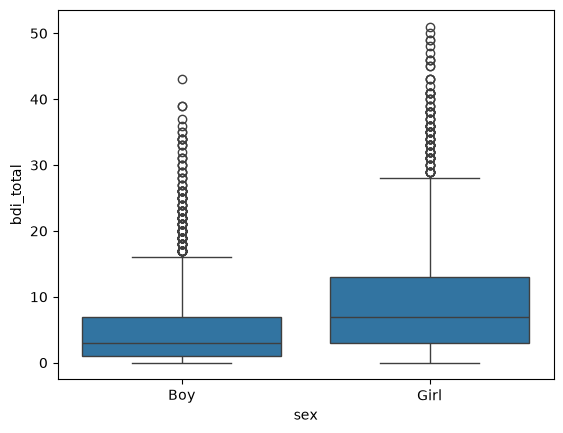

In [73]:
sns.boxplot(
    data=df,
    x="sex",
    y="bdi_total"
)

En relación al gráfico anterior, nos surge el siguiente contraste de hipótesis:

1 . Diferencias de BDI según sexo: ¿El nivel promedio de síntomas depresivos difiere entre chicos y chicas?


H₀: no existen diferencias significativas en bdi_total entre los grupos.

H₁: existen diferencias significativas.

In [78]:
from scipy.stats import ttest_ind

boy = df[df["sex"] == "Boy"]["bdi_total"]
girl = df[df["sex"] == "Girl"]["bdi_total"]

resultado = ttest_ind(
    girl,
    boy,
    equal_var=False
)

print("Estadístico t:", resultado.statistic)
print("p-value:", resultado.pvalue)

Estadístico t: 19.402358948990706
p-value: 2.4603223067203074e-80



Estadístico t = 19,40 → es un valor muy alto, lo que indica una diferencia/efecto considerable respecto a la hipótesis nula.

p-value = 2,46 × 10⁻⁸⁰ → es muchísimo menor que 0,05.

- **Conclusión:**

Se rechaza la hipótesis nula (H₀) y se concluye que existe una diferencia estadísticamente significativa entre los grupos/variables analizados. El análisis mostró una diferencia estadísticamente significativa entre los grupos analizados (t = 19,40; p < 0,001). Por lo tanto, se rechaza la hipótesis nula, evidenciando una asociación significativa entre las variables estudiadas.

2 . Tiempo de pantalla y síntomas depresivos: ¿Las personas con mayor tiempo de pantalla presentan mayores niveles de BDI? ¿Existe una relación significativa entre las horas de pantalla recreativa y los síntomas depresivos? Si aumentan las horas de pantalla, ¿tienden también a aumentar los valores de BDI?


Variables: est_leisure_screen_hours → horas estimadas de pantalla recreativa. 

bdi_total → puntuación de síntomas depresivos.

H₀: no existe relación significativa entre est_leisure_screen_hours y bdi_total.

H₁: existe una relación significativa entre ambas variables.

In [75]:
from scipy.stats import spearmanr

rho, p_value = spearmanr(
    df["est_leisure_screen_hours"],
    df["bdi_total"]
)

print("Coeficiente de Spearman:", rho) # (rho) → indica la intensidad y dirección de la relación.
print("p-value:", p_value) # p-value → indica si la relación es estadísticamente significativa.

Coeficiente de Spearman: 0.11993204678187785
p-value: 7.075552933125157e-17


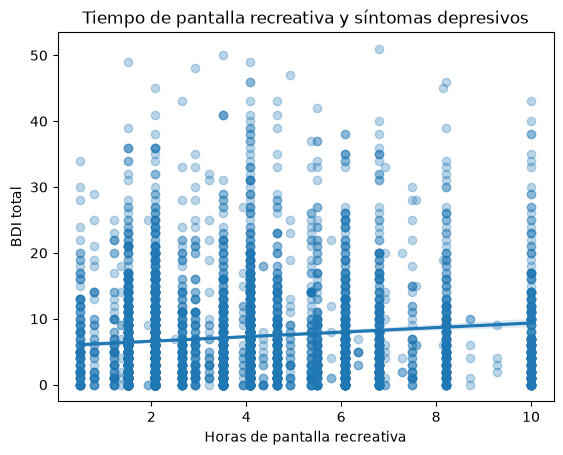

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(
    data=df,
    x="est_leisure_screen_hours",
    y="bdi_total",
    scatter_kws={"alpha": 0.3}
)

plt.title("Tiempo de pantalla recreativa y síntomas depresivos")
plt.xlabel("Horas de pantalla recreativa")
plt.ylabel("BDI total")

plt.show()

Contraste de hipótesis: Se analizó la relación entre las horas de pantalla recreativa y los síntomas depresivos mediante el coeficiente de correlación de Spearman, debido a la falta de normalidad de la variable bdi_total. Se planteó como hipótesis nula la ausencia de una relación significativa entre ambas variables y como alternativa la existencia de una relación significativa. Se utilizó un nivel de significancia de 0,05. El resultado se interpretó considerando tanto el coeficiente ρ como su p-value.

Los resultados de la correlación de Spearman son:

Coeficiente de Spearman (ρ) = 0,120: existe una correlación positiva muy débil entre las dos variables. Es decir, cuando una variable aumenta, la otra tiende a aumentar ligeramente, pero la relación es de baja intensidad.

p-value = 7,08 × 10⁻¹⁷: es mucho menor que 0,05, por lo que la correlación es estadísticamente significativa. Se rechaza la hipótesis nula de ausencia de relación.

- **Conclusión para nuestro análisis:**

Se obtuvo una correlación de Spearman positiva y estadísticamente significativa entre las variables analizadas (ρ = 0,120; p < 0,001). Sin embargo, la magnitud de la correlación es muy baja, lo que indica que, aunque existe una asociación monotónica entre ambas variables, esta relación es débil. Por lo tanto, la significancia estadística no implica una asociación de gran relevancia práctica.